# Fuel Consumption Prediction

This notebook demonstrates both:

1. **Linear Regression** – Predicts the fuel consumption in L/100 km.  
2. **Logistic Regression** – Predicts whether a car has **high (>8 L/100km)** or **low (≤8 L/100km)** fuel consumption.

Features used:

- Engine Capacity (cc)  
- Vehicle Weight (kg)  
- Mileage (km/l)  
- Average Speed (km/h)


Objective:

Predict fuel consumption of a vehicle based on engine, weight, mileage, and speed.

Classify whether the fuel consumption is High (>8 L/100 km) or Low (≤8 L/100 km) using Logistic Regression.

Features:

Engine capacity (cc)

Vehicle weight (kg)

Mileage (km/l)

Average speed (km/h)

Targets:

Linear: Fuel consumption (liters/100 km)

Logistic: High/Low consumption (binary)

Name: Vartika yadav, Rolll no.:2300291520202, CSE(AI)-C

In [9]:
# Data manipulation
import pandas as pd
import numpy as np

# Machine learning
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")


In [10]:
# Sample dataset
data = {
    "Engine_CC": [1000, 1200, 1500, 1600, 1800, 2000, 2200, 2500],
    "Weight_KG": [900, 950, 1100, 1200, 1300, 1500, 1600, 1800],
    "Mileage_KMPL": [20, 18, 15, 14, 12, 10, 9, 8],
    "Avg_Speed_KMPH": [50, 55, 60, 65, 70, 75, 80, 85],
    "Fuel_Consumption_L100KM": [5, 5.5, 6.5, 7, 8, 9, 10, 11]
}

df = pd.DataFrame(data)

# Create binary column for Logistic Regression
df["High_Consumption"] = df["Fuel_Consumption_L100KM"].apply(lambda x: 1 if x > 8 else 0)

# Display dataset
df


,Engine_CC,Weight_KG,Mileage_KMPL,Avg_Speed_KMPH,Fuel_Consumption_L100KM,High_Consumption
0,1000,900,20,50,5.0,0
1,1200,950,18,55,5.5,0
2,1500,1100,15,60,6.5,0
3,1600,1200,14,65,7.0,0
4,1800,1300,12,70,8.0,0
5,2000,1500,10,75,9.0,1
6,2200,1600,9,80,10.0,1
7,2500,1800,8,85,11.0,1


In [18]:
# Features and target
X_lr = df[["Engine_CC","Weight_KG","Mileage_KMPL","Avg_Speed_KMPH"]]
y_lr = df["Fuel_Consumption_L100KM"]

# Split dataset
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y_lr, test_size=0.25, random_state=42)

# Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train_lr)

# Predict
y_pred_lr = lr_model.predict(X_test_lr)

# Evaluate
mse = mean_squared_error(y_test_lr, y_pred_lr)
r2 = r2_score(y_test_lr, y_pred_lr)

print("Linear Regression Results:")
print("Mean Squared Error:", mse)
print("R² Score:", r2)



Linear Regression Results:
Mean Squared Error: 0.3337647928994056
R² Score: 0.8910155778287655


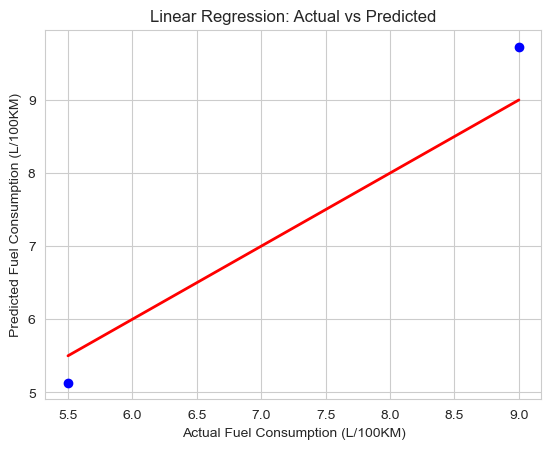

In [13]:
plt.scatter(y_test_lr, y_pred_lr, color='blue')
plt.plot([min(y_test_lr), max(y_test_lr)], [min(y_test_lr), max(y_test_lr)], color='red', linewidth=2)
plt.xlabel("Actual Fuel Consumption (L/100KM)")
plt.ylabel("Predicted Fuel Consumption (L/100KM)")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()



In [16]:
# Features and target
X_log = df[["Engine_CC","Weight_KG","Mileage_KMPL","Avg_Speed_KMPH"]]
y_log = df["High_Consumption"]

# Split dataset
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_log, y_log, test_size=0.25, random_state=42)

# Logistic Regression model
log_model = LogisticRegression()
log_model.fit(X_train_log, y_train_log)

# Predict
y_pred_log = log_model.predict(X_test_log)

# Evaluate
acc = accuracy_score(y_test_log, y_pred_log)
cm = confusion_matrix(y_test_log, y_pred_log)

print("Logistic Regression Results:")
print("Accuracy:", acc)
print("Confusion Matrix:\n", cm)



Logistic Regression Results:
Accuracy: 1.0
Confusion Matrix:
 [[1 0]
 [0 1]]


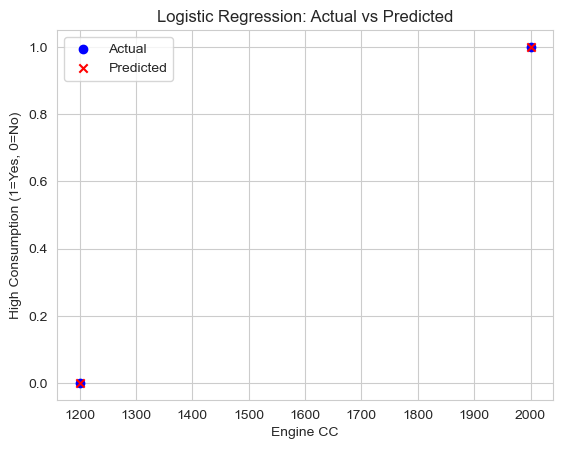

In [19]:
plt.scatter(X_test_log["Engine_CC"], y_test_log, color='blue', label='Actual')
plt.scatter(X_test_log["Engine_CC"], y_pred_log, color='red', marker='x', label='Predicted')
plt.xlabel("Engine CC")
plt.ylabel("High Consumption (1=Yes, 0=No)")
plt.title("Logistic Regression: Actual vs Predicted")
plt.legend()
plt.show()



## Conclusion

- **Linear Regression** predicts the exact fuel consumption in L/100 km.  
- **Logistic Regression** classifies cars as **High** or **Low** fuel consumers.  
- Both models use the same vehicle features, demonstrating how **continuous vs categorical predictions** are handled differently.  

This notebook can help **drivers, manufacturers, and policy makers** manage fuel efficiency and vehicle emissions.
